In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("Advertising.csv")

df.columns = df.columns.str.strip()
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print("Dataset Shape")
print(df.shape)

print("\n-Missing Values Count")
print(df.isnull().sum())

print("\nDescriptive Statistics")
display(df.describe())

print("\nCleaned DataFrame Preview")
df.head()

Dataset Shape
(200, 4)

-Missing Values Count
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Descriptive Statistics


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000



Cleaned DataFrame Preview


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


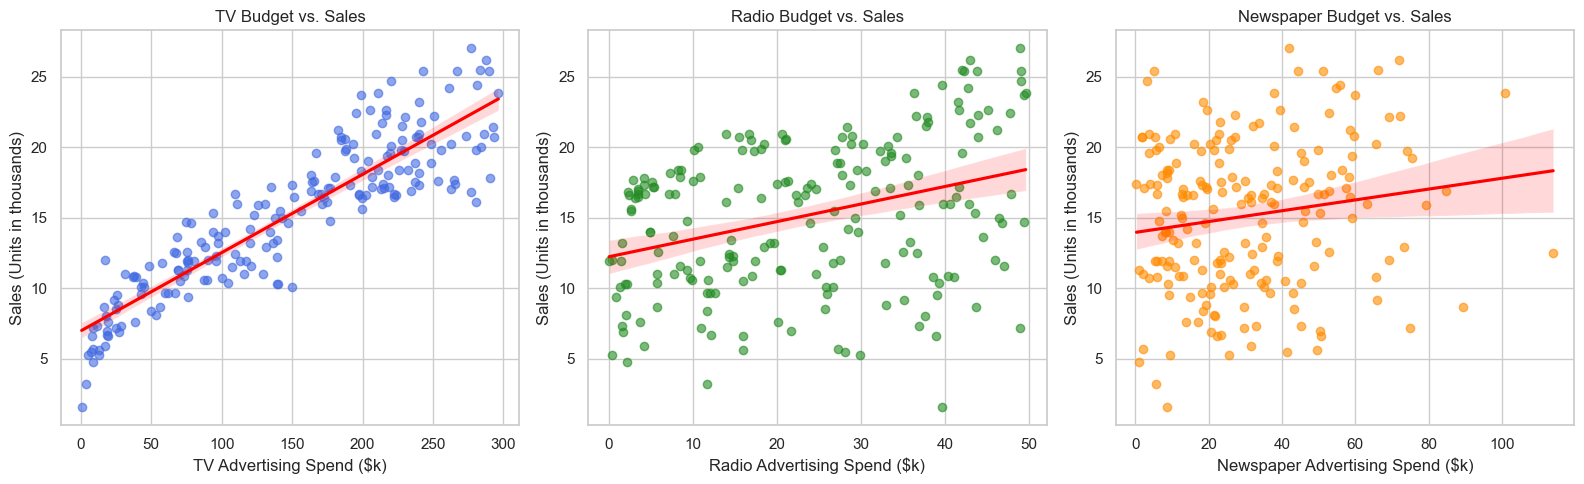

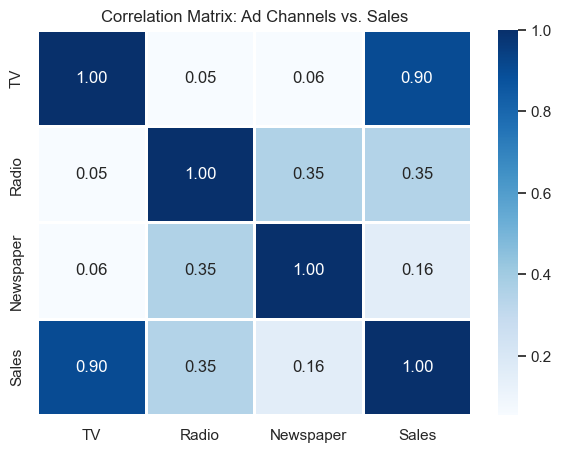

Correlation with Sales (Ranked)
Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

channels = ['TV', 'Radio', 'Newspaper']
colors = ['royalblue', 'forestgreen', 'darkorange']

for i, channel in enumerate(channels):
    sns.regplot(
        data=df, 
        x=channel, 
        y='Sales', 
        ax=axes[i], 
        color=colors[i],
        scatter_kws={'alpha': 0.6},
        line_kws={'color': 'red'}
    )
    axes[i].set_title(f"{channel} Budget vs. Sales")
    axes[i].set_xlabel(f"{channel} Advertising Spend ($k)")
    axes[i].set_ylabel("Sales (Units in thousands)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt=".2f", linewidths=0.8)
plt.title("Correlation Matrix: Ad Channels vs. Sales")
plt.show()

print("Correlation with Sales (Ranked)")
print(df.corr()['Sales'].sort_values(ascending=False))

Model Performance Benchmark


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.274826,1.705215,0.905901
1,Ridge Regression,1.274830,1.705226,0.905900
2,Random Forest Regressor,0.918000,1.198930,0.953483



Linear Regression Coefficients
Intercept (Base Sales): 4.714


,Channel,Coefficient (Weight)
1,Radio,0.100945
0,TV,0.054509
2,Newspaper,0.004337


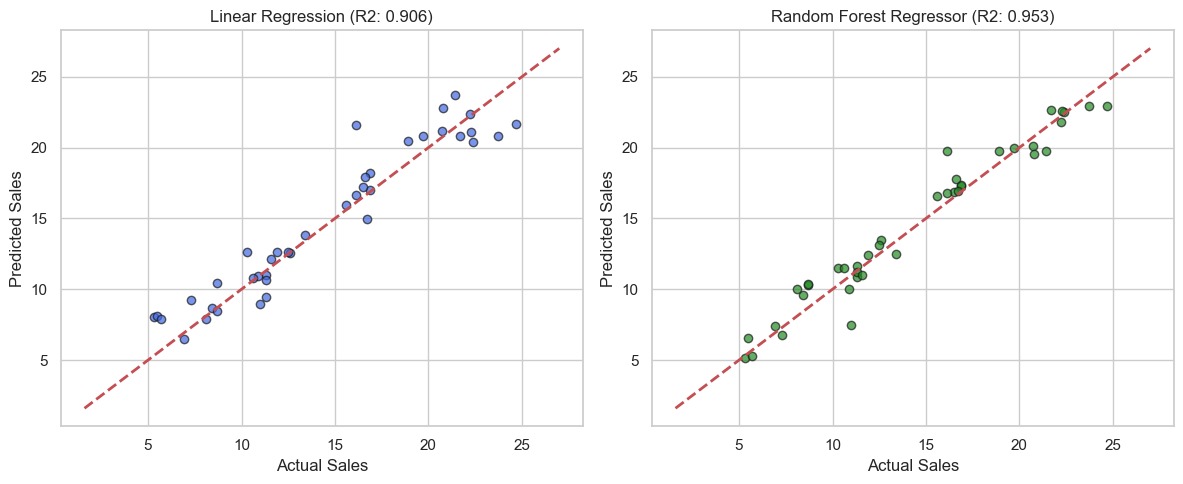

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2}

results_df = pd.DataFrame([
    evaluate_model(y_test, y_pred_lr, "Linear Regression"),
    evaluate_model(y_test, y_pred_ridge, "Ridge Regression"),
    evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")
])

print("Model Performance Benchmark")
display(results_df)

coeff_df = pd.DataFrame({
    'Channel': X.columns,
    'Coefficient (Weight)': lr.coef_
}).sort_values(by='Coefficient (Weight)', ascending=False)

print("\nLinear Regression Coefficients")
print(f"Intercept (Base Sales): {lr.intercept_:.3f}")
display(coeff_df)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, color='royalblue', edgecolors='k', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title(f"Linear Regression (R2: {r2_score(y_test, y_pred_lr):.3f})")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf, color='forestgreen', edgecolors='k', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title(f"Random Forest Regressor (R2: {r2_score(y_test, y_pred_rf):.3f})")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.tight_layout()
plt.show()